In [1]:
# ===============================================================
# Machine Learning Mid-Term Project
# "A Century of Portraits" – Single & Multi-Task Learning
# With Safe Checkpoint Resume + Best Model Saving
# ===============================================================
import os, zipfile, numpy as np, pandas as pd
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error, accuracy_score, f1_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

In [2]:
# ===============================================================
# UNZIP AND CONFIGURATION
# ===============================================================
import os, zipfile, torch

zip_path = "/content/data.zip"
extract_dir = "/content/data"

# Unzip dataset
os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(" Extraction complete! Folder contents:")
!ls -R "$extract_dir" | head -50


sub_dir = os.path.join(extract_dir, "data")

train_txt_F = os.path.join(sub_dir, "train_F.txt")
train_txt_M = os.path.join(sub_dir, "train_M.txt")
test_txt_F  = os.path.join(sub_dir, "test_F.txt")
test_txt_M  = os.path.join(sub_dir, "test_M.txt")

merged_train = os.path.join(sub_dir, "train_all.txt")
merged_test  = os.path.join(sub_dir, "test_all.txt")

# Merge both genders into one combined file
with open(merged_train, "w") as out:
    for f in [train_txt_F, train_txt_M]:
        if os.path.exists(f):
            with open(f, "r") as infile:
                out.write(infile.read())

with open(merged_test, "w") as out:
    for f in [test_txt_F, test_txt_M]:
        if os.path.exists(f):
            with open(f, "r") as infile:
                out.write(infile.read())

print(f" Merged splits created:\nTrain: {merged_train}\nTest: {merged_test}")

# ===============================================================
# CONFIGURATION CLASS
# ===============================================================
class CFG:
    img_size = 224
    batch_size = 32
    num_workers = 2
    epochs = 25
    lr = 1e-4
    ckpt_single = "best_single_checkpoint.pth"
    ckpt_multi = "best_multi_checkpoint.pth"
    train_csv = merged_train
    test_csv = merged_test
    data_root = sub_dir

# Device selection
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Verify gender balance
df_train = pd.read_csv(CFG.train_csv, sep=" ", header=None, names=["path", "label"])
print("Train gender counts:\n", df_train["path"].str[0].value_counts())

df_test = pd.read_csv(CFG.test_csv, sep=" ", header=None, names=["path", "label"])
print("Test gender counts:\n", df_test["path"].str[0].value_counts())

# ===============================================================
#  DATASET SUMMARY (Totals + Ratios)
# ===============================================================
train_counts = df_train["path"].str[0].value_counts().to_dict()
test_counts  = df_test["path"].str[0].value_counts().to_dict()

F_train = train_counts.get("F", 0)
M_train = train_counts.get("M", 0)
F_test  = test_counts.get("F", 0)
M_test  = test_counts.get("M", 0)

total_train = F_train + M_train
total_test  = F_test + M_test
train_ratio = 100 * total_train / (total_train + total_test)
test_ratio  = 100 * total_test  / (total_train + total_test)

print("\n DATASET SUMMARY")
print(f"Train gender counts:  F: {F_train:,} | M: {M_train:,}")
print(f"Test  gender counts:  F: {F_test:,} | M: {M_test:,}")
print("-----------------------------------------")
print(f"Total Train: {total_train:,}")
print(f"Total Test:  {total_test:,}")
print(f"Split Ratio: Train {train_ratio:.1f}% / Test {test_ratio:.1f}%")

 Extraction complete! Folder contents:
/content/data:
data

/content/data/data:
F
M
test_F.txt
test_M.txt
train_F.txt
train_M.txt

/content/data/data/F:
1905_Ohio_Cleveland_Central_0-1.png
1905_Ohio_Cleveland_Central_1-3.png
1906_Ohio_Cleveland_Central_0-3.png
1908_California_Los-Angeles_Los-Angeles-High_2-5.png
1908_California_Los-Angeles_Los-Angeles-High_3-1.png
1908_California_Los-Angeles_Los-Angeles-High_3-5.png
1908_California_Los-Angeles_Los-Angeles-High_5-1.png
1908_California_Los-Angeles_Los-Angeles-High_6-1.png
1908_Washington_Bellingham_Bellingham_11-0.png
1908_Washington_Bellingham_Bellingham_1-3.png
1908_Washington_Bellingham_Bellingham_14-0.png
1908_Washington_Bellingham_Bellingham_16-3.png
1908_Washington_Bellingham_Bellingham_18-0.png
1908_Washington_Bellingham_Bellingham_20-0.png
1908_Washington_Bellingham_Bellingham_6-1.png
1908_Washington_Bellingham_Bellingham_7-0.png
1908_Washington_Bellingham_Bellingham_7-2.png
1908_Washington_Bellingham_Bellingham_8-0.png
1908_Wash

In [3]:
# ===============================================================
# CUSTOM DATASET
# ===============================================================
class PortraitDataset(Dataset):
    def __init__(self, txt_file, root_dir, transform=None, multitask=False):
        self.root_dir = root_dir
        self.transform = transform
        self.multitask = multitask
        self.df = pd.read_csv(txt_file, sep=" ", header=None, names=["path", "label"])
        self.df["gender"] = self.df["path"].apply(lambda p: 0 if p.startswith("M/") else 1)
        self.df["year"] = self.df["path"].str.extract(r"(\d{4})").astype(int)
        self.min_year = self.df["year"].min()
        self.max_year = self.df["year"].max()
        self.df["year_norm"] = (self.df["year"] - self.min_year) / (self.max_year - self.min_year)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["path"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        year = torch.tensor(row["year_norm"], dtype=torch.float32)
        if self.multitask:
            gender = torch.tensor(row["gender"], dtype=torch.long)
            return image, year, gender
        else:
            return image, year


In [4]:
# ===============================================================
# TRANSFORMS
# ===============================================================
transform = transforms.Compose([
    transforms.Resize((CFG.img_size, CFG.img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [5]:
# ===============================================================
# LOADERS (SINGLE)
# ===============================================================
train_dataset_single = PortraitDataset(CFG.train_csv, CFG.data_root, transform, multitask=False)
test_dataset_single  = PortraitDataset(CFG.test_csv, CFG.data_root, transform, multitask=False)
train_loader_single = DataLoader(train_dataset_single, batch_size=CFG.batch_size, shuffle=True, num_workers=CFG.num_workers)
test_loader_single  = DataLoader(test_dataset_single, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers)
print(f" Single-task data ready: {len(train_dataset_single)} train, {len(test_dataset_single)} test samples.")


 Single-task data ready: 29506 train, 7761 test samples.


In [6]:
# ===============================================================
#  LOADERS (MULTI-TASK)
# ===============================================================
train_dataset_multi = PortraitDataset(CFG.train_csv, CFG.data_root, transform, multitask=True)
test_dataset_multi  = PortraitDataset(CFG.test_csv, CFG.data_root, transform, multitask=True)

train_loader_multi = DataLoader(
    train_dataset_multi,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=CFG.num_workers
)
test_loader_multi = DataLoader(
    test_dataset_multi,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers
)

print(f" Multi-task data ready: {len(train_dataset_multi)} train, {len(test_dataset_multi)} test samples.")


 Multi-task data ready: 29506 train, 7761 test samples.


In [7]:
# ===============================================================
#  MODELS
# ===============================================================
from torchvision.models import resnet18, ResNet18_Weights

class YearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, 1)
    def forward(self, x):
        return self.backbone(x).squeeze(1)

class MultiTaskModel(nn.Module):
    def __init__(self):
        super().__init__()
        base = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        in_feats = base.fc.in_features
        base.fc = nn.Identity()
        self.backbone = base
        self.year_head = nn.Linear(in_feats, 1)
        self.gender_head = nn.Linear(in_feats, 2)
    def forward(self, x):
        feats = self.backbone(x)
        return self.year_head(feats).squeeze(1), self.gender_head(feats)


In [8]:
# ===============================================================
#  TRAIN/EVAL FUNCTIONS
# ===============================================================
def train_single(model, loader, optimizer, criterion):
    model.train()
    total = 0
    for imgs, years in tqdm(loader, desc="Train Single"):
        imgs, years = imgs.to(DEVICE), years.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, years)
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / len(loader)

def eval_single(model, loader):
    model.eval()
    preds, targs = [], []
    with torch.no_grad():
        for imgs, years in tqdm(loader, desc="Eval Single"):
            imgs, years = imgs.to(DEVICE), years.to(DEVICE)
            out = model(imgs)
            preds.extend(out.cpu().numpy())
            targs.extend(years.cpu().numpy())
    return mean_absolute_error(targs, preds)

def train_multi(model, loader, optimizer, c_year, c_gender, λy=0.7, λg=0.3):
    model.train()
    total = 0
    for imgs, years, genders in tqdm(loader, desc="Train Multi"):
        imgs, years, genders = imgs.to(DEVICE), years.to(DEVICE), genders.to(DEVICE)
        optimizer.zero_grad()
        y_out, g_out = model(imgs)
        loss = λy * c_year(y_out, years) + λg * c_gender(g_out, genders)
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / len(loader)

def eval_multi(model, loader, ymin, ymax):
    model.eval()
    p_y, t_y, p_g, t_g = [], [], [], []
    with torch.no_grad():
        for imgs, years, genders in tqdm(loader, desc="Eval Multi"):
            imgs, years, genders = imgs.to(DEVICE), years.to(DEVICE), genders.to(DEVICE)
            y_out, g_out = model(imgs)
            p_y.extend(y_out.cpu().numpy())
            t_y.extend(years.cpu().numpy())
            p_g.extend(torch.argmax(g_out, 1).cpu().numpy())
            t_g.extend(genders.cpu().numpy())
    mae = mean_absolute_error(t_y, p_y)
    acc = accuracy_score(t_g, p_g)
    f1  = f1_score(t_g, p_g)
    print(f"MAE: {mae*(ymax-ymin):.2f} years | Gender Acc: {acc*100:.2f}% | F1: {f1:.3f}")
    return mae, acc, f1

In [9]:
# ===============================================================
#  Single-Task Model with BEST + LATEST Checkpoints
# ===============================================================
import os, torch, matplotlib.pyplot as plt

# Define checkpoint file paths
ckpt_latest = CFG.ckpt_single.replace(".pth", "_latest.pth")
ckpt_best   = CFG.ckpt_single.replace(".pth", "_best.pth")

# Initialize model, optimizer, scheduler, criterion
single = YearRegressionModel().to(DEVICE)
opt = torch.optim.Adam(single.parameters(), lr=CFG.lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)
crit = nn.L1Loss()




Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


In [10]:
# ===============================================================
# Load Best or Latest Checkpoint if Available
# ===============================================================
if os.path.exists(ckpt_latest):
    ckpt = torch.load(ckpt_latest, map_location=DEVICE)
    single.load_state_dict(ckpt["model_state"])
    opt.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt.get("scheduler_state", scheduler.state_dict()))
    start_epoch = ckpt.get("epoch", 0)
    best_mae = ckpt.get("best_mae", float("inf"))
    loss_log = ckpt.get("loss_log", [])
    mae_log = ckpt.get("mae_log", [])
    print(f" Resuming from latest checkpoint (epoch {start_epoch}) | Best MAE so far: {best_mae:.2f}")
elif os.path.exists(ckpt_best):
    ckpt = torch.load(ckpt_best, map_location=DEVICE)
    single.load_state_dict(ckpt["model_state"])
    opt.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt.get("scheduler_state", scheduler.state_dict()))
    start_epoch = ckpt.get("epoch", 0)
    best_mae = ckpt.get("best_mae", float("inf"))
    loss_log = ckpt.get("loss_log", [])
    mae_log = ckpt.get("mae_log", [])
    print(f" Loaded best model (epoch {start_epoch}) | Best MAE: {best_mae:.2f}")
else:
    ckpt = {
        "epoch": 0,
        "best_mae": float("inf"),
        "model_state": single.state_dict(),
        "optimizer_state": opt.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "loss_log": [],
        "mae_log": [],
        "config": {k: getattr(CFG, k) for k in dir(CFG) if not k.startswith("__")}
    }
    torch.save(ckpt, ckpt_latest)
    start_epoch, best_mae, loss_log, mae_log = 0, float("inf"), [], []
    print(f" Starting training from scratch — created '{ckpt_latest}'")

 Starting training from scratch — created 'best_single_checkpoint_latest.pth'


In [11]:
# ===============================================================
#  TRAINING LOOP
# ===============================================================
for ep in range(start_epoch, CFG.epochs):
    loss = train_single(single, train_loader_single, opt, crit)
    mae = eval_single(single, test_loader_single)
    mae_real = mae * (train_dataset_single.max_year - train_dataset_single.min_year)
    scheduler.step(mae_real)

    loss_log.append(loss)
    mae_log.append(mae_real)

    print(f"[Single] {ep+1}/{CFG.epochs} | Loss={loss:.4f} | MAE={mae_real:.2f} years")

    # --- Update checkpoint info ---
    ckpt.update({
        "epoch": ep + 1,
        "model_state": single.state_dict(),
        "optimizer_state": opt.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "loss_log": loss_log,
        "mae_log": mae_log,
    })

    # ---  Save latest (for resume) ---
    torch.save(ckpt, ckpt_latest)

    # ---  Save best model if MAE improves ---
    if mae_real < best_mae:
        best_mae = mae_real
        ckpt["best_mae"] = best_mae
        torch.save(ckpt, ckpt_best)
        print(f" Best model saved! MAE improved to {best_mae:.2f} years")

Eval Single: 100%|██████████| 243/243 [00:22<00:00, 10.69it/s]


[Single] 1/25 | Loss=0.0960 | MAE=14.72 years
 Best model saved! MAE improved to 14.72 years


Eval Single: 100%|██████████| 243/243 [00:23<00:00, 10.34it/s]


[Single] 2/25 | Loss=0.0576 | MAE=12.16 years
 Best model saved! MAE improved to 12.16 years


Eval Single: 100%|██████████| 243/243 [00:22<00:00, 10.99it/s]


...

[Single] 23/25 | Loss=0.0047 | MAE=11.67 years


Eval Single: 100%|██████████| 243/243 [00:23<00:00, 10.17it/s]


[Single] 24/25 | Loss=0.0041 | MAE=11.61 years


Eval Single: 100%|██████████| 243/243 [00:23<00:00, 10.16it/s]


[Single] 25/25 | Loss=0.0040 | MAE=11.73 years


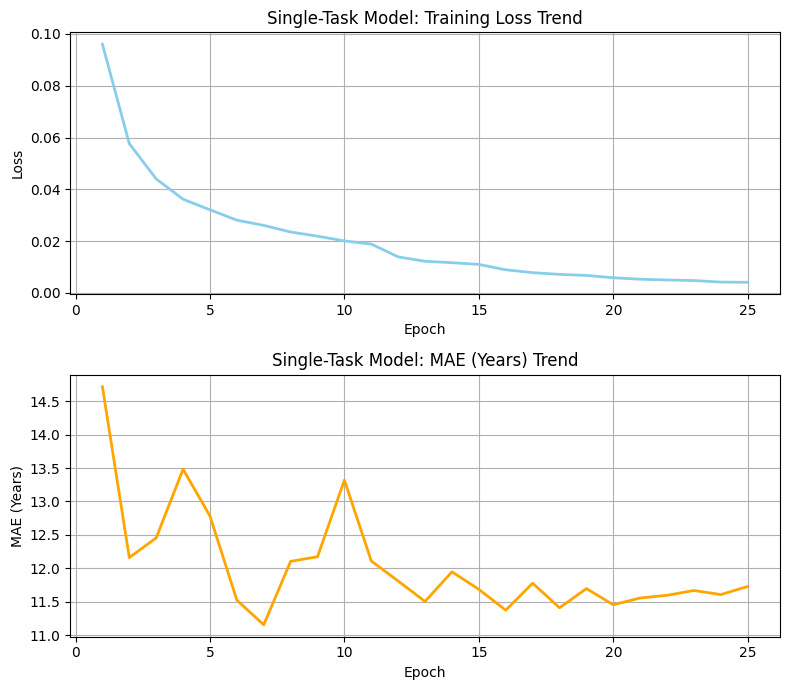

 Training complete! Best MAE achieved: 11.15 years
 Best checkpoint: best_single_checkpoint_best.pth
 Latest checkpoint: best_single_checkpoint_latest.pth


In [12]:
# ===============================================================
#  VISUALIZE LOSS & MAE
# ===============================================================
import matplotlib.pyplot as plt

epochs = range(1, len(loss_log) + 1)

plt.figure(figsize=(8, 7))

# ---------- Graph 1: Training Loss ----------
plt.subplot(2, 1, 1)
plt.plot(epochs, loss_log, color='skyblue', linewidth=2)
plt.title('Single-Task Model: Training Loss Trend')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# ---------- Graph 2: MAE ----------
plt.subplot(2, 1, 2)
plt.plot(epochs, mae_log, color='orange', linewidth=2)
plt.title('Single-Task Model: MAE (Years) Trend')
plt.xlabel('Epoch')
plt.ylabel('MAE (Years)')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f" Training complete! Best MAE achieved: {best_mae:.2f} years")
print(f" Best checkpoint: {ckpt_best}")
print(f" Latest checkpoint: {ckpt_latest}")


In [13]:
# ===============================================================
#  Multi-Task Model
# ===============================================================
import os, torch

# Define checkpoint paths
ckpt_latest = CFG.ckpt_multi.replace(".pth", "_latest.pth")
ckpt_best   = CFG.ckpt_multi.replace(".pth", "_best.pth")

# Initialize model, optimizer, scheduler, loss functions
multi = MultiTaskModel().to(DEVICE)
opt = torch.optim.Adam(multi.parameters(), lr=CFG.lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=2)
crit_year = nn.L1Loss()
crit_gender = nn.CrossEntropyLoss(label_smoothing=0.05)

In [14]:
# ===============================================================
# Load Best or Latest Checkpoint if Available
# ===============================================================
if os.path.exists(ckpt_latest):
    ckpt = torch.load(ckpt_latest, map_location=DEVICE)
    multi.load_state_dict(ckpt["model_state"])
    opt.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt.get("scheduler_state", scheduler.state_dict()))
    start_epoch = ckpt.get("epoch", 0)
    best_mae = ckpt.get("best_mae", float("inf"))
    loss_log = ckpt.get("loss_log", [])
    mae_log = ckpt.get("mae_log", [])
    acc_log = ckpt.get("acc_log", [])
    f1_log  = ckpt.get("f1_log", [])
    print(f" Resuming from latest checkpoint (epoch {start_epoch}) | Best MAE: {best_mae:.2f}")
elif os.path.exists(ckpt_best):
    ckpt = torch.load(ckpt_best, map_location=DEVICE)
    multi.load_state_dict(ckpt["model_state"])
    opt.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt.get("scheduler_state", scheduler.state_dict()))
    start_epoch = ckpt.get("epoch", 0)
    best_mae = ckpt.get("best_mae", float("inf"))
    loss_log = ckpt.get("loss_log", [])
    mae_log = ckpt.get("mae_log", [])
    acc_log = ckpt.get("acc_log", [])
    f1_log  = ckpt.get("f1_log", [])
    print(f" Loaded best model (epoch {start_epoch}) | Best MAE: {best_mae:.2f}")
else:
    ckpt = {
        "epoch": 0,
        "best_mae": float("inf"),
        "model_state": multi.state_dict(),
        "optimizer_state": opt.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "loss_log": [],
        "mae_log": [],
        "acc_log": [],
        "f1_log": [],
        "config": {k: getattr(CFG, k) for k in dir(CFG) if not k.startswith('__')},
    }
    torch.save(ckpt, ckpt_latest)
    start_epoch, best_mae = 0, float("inf")
    loss_log, mae_log, acc_log, f1_log = [], [], [], []
    print(f" Starting training from scratch — created '{ckpt_latest}'")

 Starting training from scratch — created 'best_multi_checkpoint_latest.pth'


In [16]:
# ===============================================================
#  TRAINING LOOP
# ===============================================================
for ep in range(start_epoch, CFG.epochs):
    loss = train_multi(multi, train_loader_multi, opt, crit_year, crit_gender)
    mae, acc, f1 = eval_multi(
        multi, test_loader_multi, train_dataset_multi.min_year, train_dataset_multi.max_year
    )
    mae_real = mae * (train_dataset_multi.max_year - train_dataset_multi.min_year)
    scheduler.step(mae_real)

    # Log metrics
    loss_log.append(loss)
    mae_log.append(mae_real)
    acc_log.append(acc)
    f1_log.append(f1)

    print(f"[Multi] {ep+1}/{CFG.epochs} | Loss={loss:.4f} | "
          f"MAE={mae_real:.2f} | Acc={acc*100:.2f}% | F1={f1:.3f}")

    # --- Update checkpoint ---
    ckpt.update({
        "epoch": ep + 1,
        "model_state": multi.state_dict(),
        "optimizer_state": opt.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "loss_log": loss_log,
        "mae_log": mae_log,
        "acc_log": acc_log,
        "f1_log": f1_log,
    })

    # ---  Save latest checkpoint (for resume) ---
    torch.save(ckpt, ckpt_latest)

    # ---  Save best model (for evaluation) ---
    if mae_real < best_mae:
        best_mae = mae_real
        ckpt["best_mae"] = best_mae
        torch.save(ckpt, ckpt_best)
        print(f" Best model saved! MAE improved to {best_mae:.2f} years")

print(f" Training complete! Best MAE achieved: {best_mae:.2f} years")
print(f"Best checkpoint: {ckpt_best}")
print(f"Latest checkpoint: {ckpt_latest}")

Eval Multi: 100%|██████████| 243/243 [00:24<00:00, 10.10it/s]


MAE: 12.06 years | Gender Acc: 95.53% | F1: 0.959
[Multi] 1/25 | Loss=0.0704 | MAE=12.06 | Acc=95.53% | F1=0.959
 Best model saved! MAE improved to 12.06 years


Eval Multi: 100%|██████████| 243/243 [00:24<00:00,  9.85it/s]


MAE: 13.20 years | Gender Acc: 95.32% | F1: 0.959
[Multi] 2/25 | Loss=0.0655 | MAE=13.20 | Acc=95.32% | F1=0.959


Eval Multi: 100%|██████████| 243/243 [00:24<00:00, 10.08it/s]


...

MAE: 12.09 years | Gender Acc: 96.39% | F1: 0.967
[Multi] 21/25 | Loss=0.0390 | MAE=12.09 | Acc=96.39% | F1=0.967


Eval Multi: 100%|██████████| 243/243 [00:24<00:00,  9.74it/s]


MAE: 12.16 years | Gender Acc: 96.41% | F1: 0.967
[Multi] 22/25 | Loss=0.0384 | MAE=12.16 | Acc=96.41% | F1=0.967


Eval Multi:  59%|█████▉    | 144/243 [00:14<00:10,  9.80it/s]


KeyboardInterrupt: 

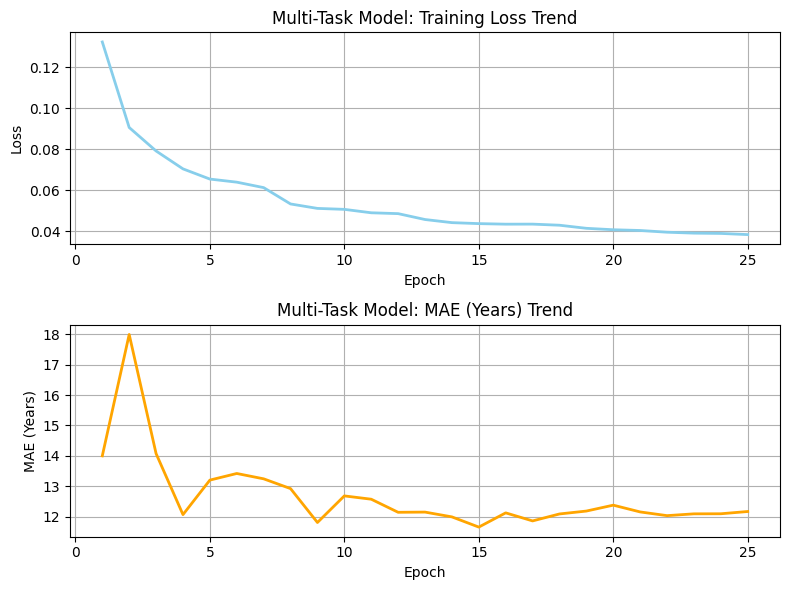

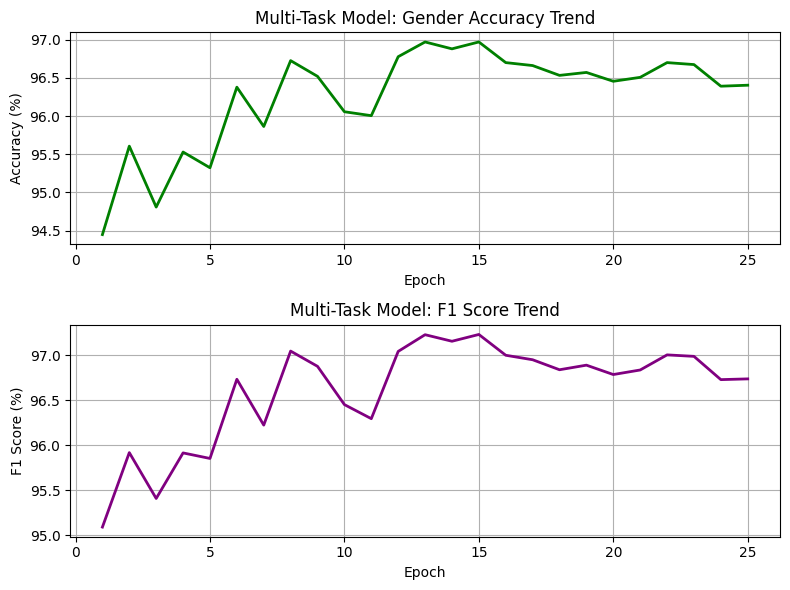

 Final Performance — Best MAE: 11.65 years
 Final Gender Accuracy: 96.41% | Final F1: 96.74%


In [17]:
# ===============================================================
# VISUALIZATION: Multi-Task Metrics
# ===============================================================
import matplotlib.pyplot as plt

epochs = range(1, len(loss_log) + 1)

# ----------  Loss & MAE (Years) ----------
plt.figure(figsize=(8, 6))
plt.subplot(2, 1, 1)
plt.plot(epochs, loss_log, color='skyblue', linewidth=2)
plt.title('Multi-Task Model: Training Loss Trend')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(epochs, mae_log, color='orange', linewidth=2)
plt.title('Multi-Task Model: MAE (Years) Trend')
plt.xlabel('Epoch')
plt.ylabel('MAE (Years)')
plt.grid(True)
plt.tight_layout()
plt.show()

# ----------  Gender Accuracy & F1 ----------
plt.figure(figsize=(8, 6))
plt.subplot(2, 1, 1)
plt.plot(epochs, [a*100 for a in acc_log], color='green', linewidth=2)
plt.title('Multi-Task Model: Gender Accuracy Trend')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(epochs, [f*100 for f in f1_log], color='purple', linewidth=2)
plt.title('Multi-Task Model: F1 Score Trend')
plt.xlabel('Epoch')
plt.ylabel('F1 Score (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f" Final Performance — Best MAE: {best_mae:.2f} years")
print(f" Final Gender Accuracy: {acc_log[-1]*100:.2f}% | Final F1: {f1_log[-1]*100:.2f}%")
